# Relatório Executivo: Bares, Restaurantes e Alimentação Fora do Lar
**Fonte:** Dados Públicos de CNPJ da Receita Federal (Brasil todo, competência 2026-08).  
**Recorte:** 6 CNAEs do setor (5611-2/01, 5611-2/03, 5611-2/04, 5611-2/05, 5620-1/04 e 4721-1/02).

---

### Resumo Executivo das Respostas

| Pergunta | Resposta Oficial | Destaque |
|---|---|---|
| **1. Empresas ativas hoje** | **1.511.132 empresas** | 97,6% são matrizes (negócio de ponto único) |
| **2. Aberturas nos últimos 5 anos** | **1.507.905 empresas abertas** entre 2021 e 2025 | Pico em 2021 (356.849) e 315.376 em 2025 |
| **3. Porte predominante** | **MEI lidera com 63,1%** | Microempresa (ME) vem em seguida com 32,2% |


## 1. Conexão com os Dados Tratados
Carregamos os dados analíticos consolidados via DuckDB:

In [1]:
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Paleta usada no dashboard, reaproveitada nas tabelas e gráficos técnicos.
CORES = {
    'terracota': '#E0533C',
    'laranja': '#F08C28',
    'oliva': '#4E8752',
    'azul': '#3B728C',
    'azul_claro': '#9ABECF',
    'ameixa': '#8B5E83',
    'bege': '#D5C9BF',
    'grade': '#EADFD7',
}
plt.rcParams.update({
    'figure.facecolor': '#F5EFEB', 'axes.facecolor': '#FFFFFF',
    'axes.titleweight': 'bold', 'axes.titlecolor': '#2D231E',
    'axes.labelcolor': '#5C4D44', 'xtick.color': '#5C4D44',
    'ytick.color': '#5C4D44', 'font.size': 11,
})

def tabela(df):
    return (df.style
        .format(precision=1, thousands='.', decimal=',')
        .set_properties(**{'background-color': '#FAF6F0', 'color': '#2D231E', 'padding': '8px 12px'})
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#E0533C'), ('color', 'white'), ('padding', '8px 12px')]},
            {'selector': 'table', 'props': [('border-collapse', 'separate'), ('border-spacing', '0 4px')]},
        ]))

def finalizar_grafico(ax, eixo_grade):
    ax.grid(axis=eixo_grade, color=CORES['grade'], linewidth=1.1)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(CORES['grade'])
    ax.spines['bottom'].set_color(CORES['grade'])

# Localiza os dados tratados.
RAIZ = Path.cwd() if (Path.cwd() / 'dados').exists() else Path.cwd().parent
con = duckdb.connect()
con.execute(f"CREATE VIEW base AS SELECT * FROM read_parquet('{RAIZ}/dados/tratados/base_afl.parquet')")

total = con.sql('''
    SELECT count(*) AS total_estabelecimentos,
           count(DISTINCT cnpj_basico) AS total_empresas
    FROM base
''').df()
display(tabela(total))


,total_estabelecimentos,total_empresas
0,5.224.132,5.129.800


---
## 2. Pergunta 1: Quantas empresas do setor estão ativas hoje?

No cadastro da Receita, cada ponto físico é um **estabelecimento**. Empresas distintas são identificadas pelo **CNPJ básico** (8 primeiros dígitos).

In [2]:
# 1. Total de empresas ativas e estabelecimentos ativos.
ativas = con.sql('''
    SELECT
        count(DISTINCT cnpj_basico) AS empresas_ativas,
        count(*) AS estabelecimentos_ativos
    FROM base
    WHERE situacao = 'Ativa'
''').df()
display(tabela(ativas))


,empresas_ativas,estabelecimentos_ativos
0,1.511.132,1.543.267


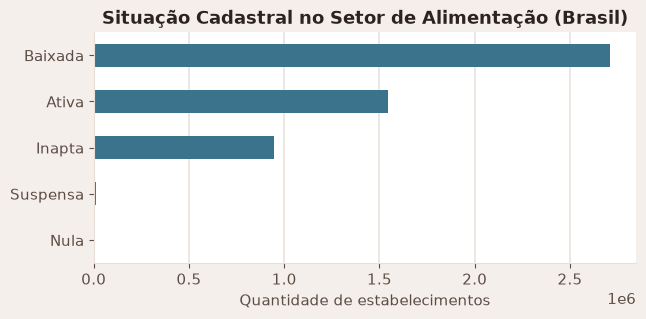

In [3]:
# 2. Distribuição da situação cadastral do setor.
situacao = con.sql('''
    SELECT situacao, count(*) AS total
    FROM base
    GROUP BY 1
    ORDER BY total ASC
''').df()

ax = situacao.plot.barh(
    x='situacao', y='total', legend=False,
    color=CORES['azul'], figsize=(7, 3)
)
ax.set_title('Situação Cadastral no Setor de Alimentação (Brasil)')
ax.set_xlabel('Quantidade de estabelecimentos')
ax.set_ylabel('')
finalizar_grafico(ax, 'x')


* **Insight:** Mais de 2,7 milhões de CNPJs do setor já foram baixados ao longo da história. O setor tem alta rotatividade de abertura e fechamento.

---
## 3. Pergunta 2: Como evoluiu a abertura de empresas nos últimos 5 anos?

Consideramos cinco anos completos, de **2021 a 2025**, usando a data de início de atividade de cada estabelecimento.


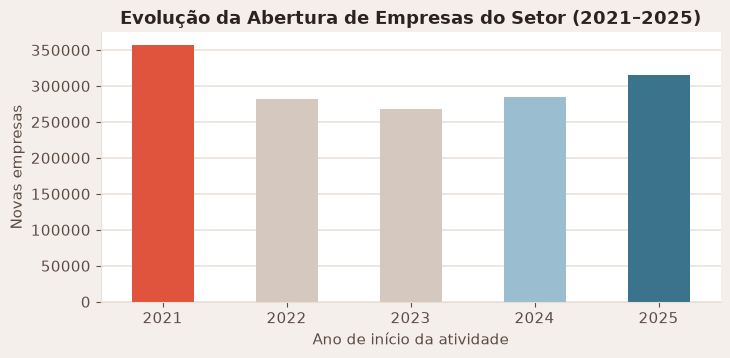

In [4]:
# Aberturas anuais do período pedido: 2021 a 2025.
aberturas = con.sql('''
    SELECT ano_inicio AS ano, count(*) AS novas_aberturas
    FROM base
    WHERE ano_inicio BETWEEN 2021 AND 2025
    GROUP BY 1
    ORDER BY 1
''').df()

ax = aberturas.plot.bar(
    x='ano', y='novas_aberturas', legend=False, rot=0, figsize=(8, 3.5),
    color=[CORES['terracota'], CORES['bege'], CORES['bege'], CORES['azul_claro'], CORES['azul']]
)
ax.set_title('Evolução da Abertura de Empresas do Setor (2021–2025)')
ax.set_xlabel('Ano de início da atividade')
ax.set_ylabel('Novas empresas')
finalizar_grafico(ax, 'y')


In [5]:
# Participação do setor entre todas as aberturas do Brasil.
participacao = con.sql(f'''
    SELECT
        s.ano,
        s.aberturas AS aberturas_setor,
        p.aberturas AS aberturas_brasil,
        round(100.0 * s.aberturas / p.aberturas, 1) AS share_pct
    FROM (SELECT ano_inicio AS ano, count(*) AS aberturas FROM base GROUP BY 1) s
    JOIN read_csv('{RAIZ}/dados/tratados/aberturas_pais_por_ano.csv') p ON s.ano = p.ano
    WHERE s.ano BETWEEN 2021 AND 2025
    ORDER BY s.ano
''').df()
display(tabela(participacao))


,ano,aberturas_setor,aberturas_brasil,share_pct
0,2.021,356.849,4.139.548,"8,6"
1,2.022,282.586,3.977.554,"7,1"
2,2.023,268.190,3.984.872,"6,7"
3,2.024,284.904,4.844.030,"5,9"
4,2.025,315.376,5.194.734,"6,1"


* **Insight:** Entre 2021 e 2025, o setor registrou **1.507.905 aberturas**. O maior valor foi em 2021 (356.849); após o menor ponto em 2023 (268.190), as aberturas voltaram a crescer em 2024 e 2025 (315.376).

---
## 4. Pergunta 3: Qual o porte predominante?

O campo `porte` padrão da Receita omite o MEI (ele só classifica ME, EPP e Demais). Por isso, cruzamos com a base oficial do **Simples Nacional** para extrair o MEI com exatidão:


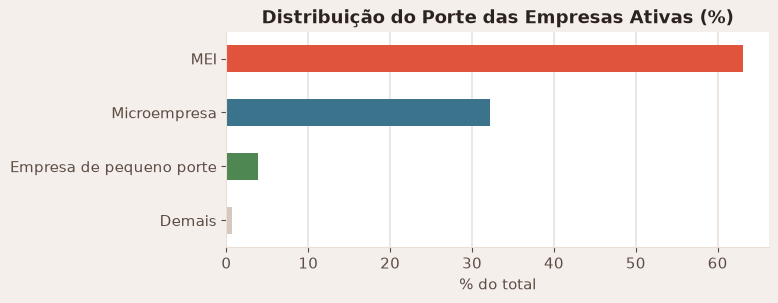

In [6]:
porte = con.sql('''
    SELECT
        CASE WHEN mei = 'MEI' THEN 'MEI' ELSE porte END AS porte_real,
        count(DISTINCT cnpj_basico) AS total_empresas
    FROM base
    WHERE situacao = 'Ativa'
    GROUP BY 1
    ORDER BY total_empresas ASC
''').df()
porte['percentual'] = (porte['total_empresas'] / porte['total_empresas'].sum() * 100).round(1)

ax = porte.plot.barh(
    x='porte_real', y='percentual', legend=False, figsize=(7, 2.8),
    color=[CORES['bege'], CORES['oliva'], CORES['azul'], CORES['terracota']]
)
ax.set_title('Distribuição do Porte das Empresas Ativas (%)')
ax.set_xlabel('% do total')
ax.set_ylabel('')
finalizar_grafico(ax, 'x')


In [7]:
display(tabela(porte.sort_values(by='total_empresas', ascending=False)))


,porte_real,total_empresas,percentual
3,MEI,953.769,"63,1"
2,Microempresa,486.715,"32,2"
1,Empresa de pequeno porte,59.403,"3,9"
0,Demais,11.245,"0,7"


* **Insight:** O setor é composto massivamente por pequenos negócios: **63,1% são MEIs** e **32,2% são Microempresas**. Apenas 4,6% são empresas de porte maior.

---
## 5. Destaques Regionais e Segmentos

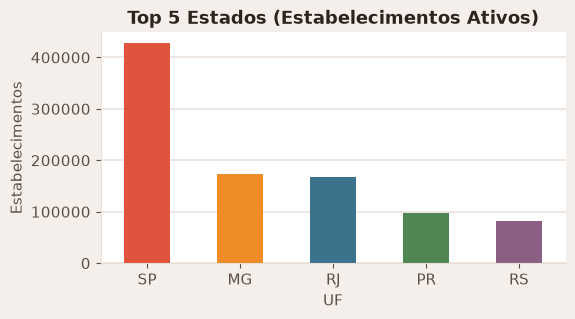

In [8]:
# Top 5 estados com mais estabelecimentos ativos.
top_ufs = con.sql('''
    SELECT uf, count(*) AS total_estabelecimentos
    FROM base
    WHERE situacao = 'Ativa'
    GROUP BY 1
    ORDER BY total_estabelecimentos DESC
    LIMIT 5
''').df()

ax = top_ufs.plot.bar(
    x='uf', y='total_estabelecimentos', legend=False, rot=0, figsize=(6, 3),
    color=[CORES['terracota'], CORES['laranja'], CORES['azul'], CORES['oliva'], CORES['ameixa']]
)
ax.set_title('Top 5 Estados (Estabelecimentos Ativos)')
ax.set_xlabel('UF')
ax.set_ylabel('Estabelecimentos')
finalizar_grafico(ax, 'y')


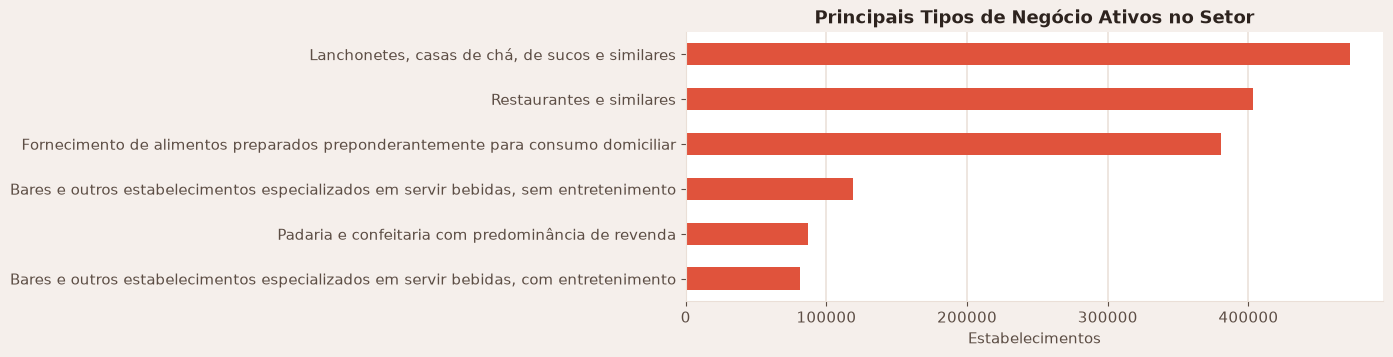

In [9]:
# Segmentos com maior volume de estabelecimentos ativos.
tipos = con.sql('''
    SELECT
        cnae_descricao AS atividade,
        count(*) AS ativos
    FROM base
    WHERE situacao = 'Ativa'
    GROUP BY 1
    ORDER BY ativos ASC
''').df()

ax = tipos.plot.barh(
    x='atividade', y='ativos', legend=False,
    color=CORES['terracota'], figsize=(9, 3.5)
)
ax.set_title('Principais Tipos de Negócio Ativos no Setor')
ax.set_xlabel('Estabelecimentos')
ax.set_ylabel('')
finalizar_grafico(ax, 'x')


---
## Conclusão Sintética

1. **Setor de pequenos negócios:** há 1,5 milhão de empresas ativas; 97,6% têm somente matriz e mais de 95% são MEI ou Microempresa.
2. **Abertura consistente:** nos cinco anos completos analisados, foram 1.507.905 empresas abertas. O pico foi em 2021 e 2025 encerrou o período com 315.376 novas empresas.
3. **São Paulo lidera:** concentra quase 28% dos estabelecimentos ativos do país.
